First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [9]:
import os

os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0"
os.environ["CUDA_HOME"] = "/usr/local/cuda-12.5"
os.environ["PATH"] = "/usr/local/cuda-12.5/bin:" + os.environ["PATH"]
os.environ["LD_LIBRARY_PATH"] = "/usr/local/cuda-12.5/lib64:" + os.environ.get("LD_LIBRARY_PATH", "")


In [ ]:
#@title Setup Repository
import os

CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive'

os.chdir(f'{CODE_DIR}')

from argparse import Namespace
import time
import os
import sys
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms

sys.path.append(".")
sys.path.append("..")

from utils.common import tensor2im
#from models.e4e_models.psp import pSp  # we use the pSp framework to load the e4e encoder.
from models.e4e_models.psp import pSp  # we use the pSp framework to load the e4e encoder.
from notebooks.def_funcs import load_sparsity_model, load_ema_model, evaluate_model, transform_images_to_batch, load_folder_images, \
    show_latent_map, visulize_singleImg_paired2, visulize_singleImg_paired3, visulize_singleImg_paired4, visulize_singleImg_paired5
# %load_ext autoreload
# %autoreload 2
%load_ext autoreload
%autoreload 2

In [3]:
# experiment_type = 'church_encode' #@param ['ffhq_encode', 'cars_encode', 'horse_encode', 'church_encode']

# EXPERIMENT_DATA_ARGS = {
#     "ffhq_encode": {
#         "model_path": "../pretrained_models/e4e_ffhq_encode.pt",
#         "image_path": "notebooks/images/input_img.jpg"
#     },
#     "cars_encode": {
#         "model_path": "../pretrained_models/e4e_models/e4e_cars_encode.pt",
#         "image_path": "notebooks/images/car_img.jpg"
#     },
#     "horse_encode": {
#         "model_path": "../pretrained_models/e4e_models/e4e_horse_encode.pt",
#         "image_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/encoder4editing-main/notebooks/images/horse_img.jpg"
#     },
#     "church_encode": {
#         "model_path": "../pretrained_models/e4e_models/e4e_church_encode.pt",
#         "image_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/encoder4editing-main/notebooks/images/church_img.jpg"
#     }
    
# }
# # Setup required image transformations
# EXPERIMENT_ARGS = EXPERIMENT_DATA_ARGS[experiment_type]
# if experiment_type == 'cars_encode':
#     EXPERIMENT_ARGS['transform'] = transforms.Compose([
#             transforms.Resize((192, 256)),
#             transforms.ToTensor(),
#             transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
#     resize_dims = (256, 192)
# else:
#     EXPERIMENT_ARGS['transform'] = transforms.Compose([
#         transforms.Resize((256, 256)),
#         transforms.ToTensor(),
#         transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
#     resize_dims = (256, 256)

In [4]:
# model_path = EXPERIMENT_ARGS['model_path']
# ckpt = torch.load(model_path, map_location='cpu')
# opts = ckpt['opts']
# # pprint.pprint(opts)  # Display full options used
# # update the training options
# opts['checkpoint_path'] = model_path
# # opts['style_dim'] = model_path
# # opts['output_size'] = model_path
# opts= Namespace(**opts)
# net = pSp(opts)
# net.eval()
# net.cuda()
# print('Model successfully loaded!')

In [ ]:
image_paths ="./notebooks/horse"
model_path = "../pretrained_models/e4e_models/e4e_horse_encode.pt"


transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
device = 'cuda'

ckpt = torch.load(model_path, map_location='cpu')
opts = ckpt['opts']
# pprint.pprint(opts)  # Display full options used
# update the training options
opts['e4e_checkpoint_path'] = model_path
# opts['style_dim'] = model_path
# opts['output_size'] = model_path

opts= Namespace(**opts)
opts.encoder_type = 'GradualStyleEncoder'
net = pSp(opts)
net.eval()
net.cuda()
print('Model successfully loaded!')

%matplotlib inline
images= load_folder_images(image_paths)


transformed_image = transform_images_to_batch(images, transform).to(device).float()

with torch.no_grad():
    tic = time.time()
    result_images, latents = net(transformed_image, randomize_noise=False, return_latents=True)
    result_images, latents = net(net.decoder, randomize_noise=False, return_latents=True)
    # result_image, latent = images[0], latents[0]
    toc = time.time()
    print('Inference took {:.4f} seconds.'.format(toc - tic))
# custom_indices = torch.tensor([0, 1, 2, 3])  # Example custom order for batch size of 4
# input_images_bg = input_images_bg[custom_indices]


Loading e4e over the pSp framework from checkpoint: ../pretrained_models/e4e_models/e4e_horse_encode.pt
Model successfully loaded!
Inference took 0.3910 seconds.


In [8]:
opts.encoder_type

'GradualStyleEncoder'

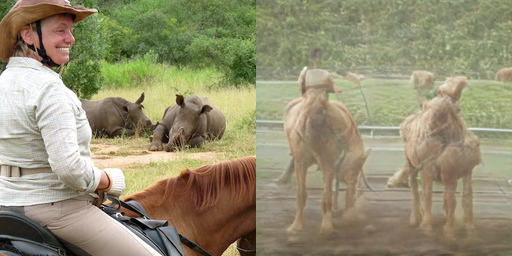

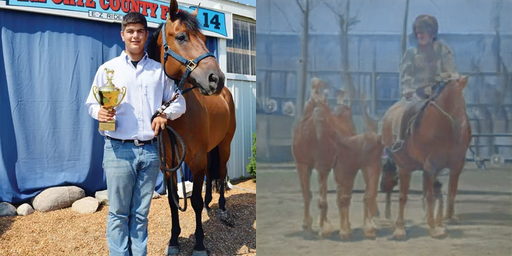

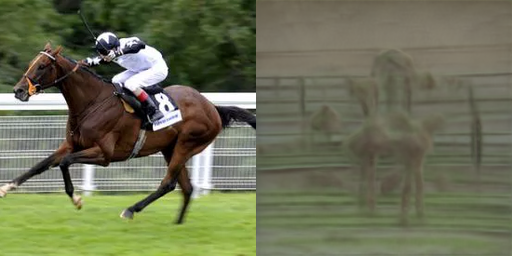

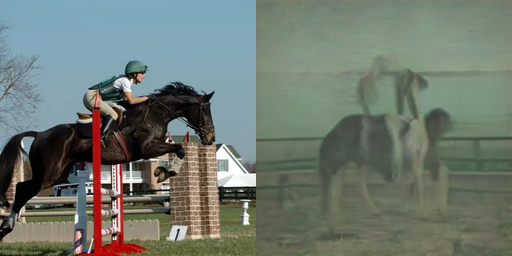

In [7]:
for i in range (4):
    visulize_singleImg_paired2(transformed_image[i,:,:,:], result_images[i,:,:,:])


### Load pretrained pSp model